# Compétition 1 : Prédiction de la Qualité de la Bière 🍺

Ce notebook fournit du code de démarrage pour la compétition de prédiction de la qualité de la bière. Pour les instructions complètes, l'énoncé du problème et les critères de notation, veuillez vous référer au fichier **README.md**.

**Résumé rapide** : Vous allez construire un modèle de classification pour prédire la qualité de la bière (scores 1-10) basé sur des propriétés chimiques. Soumettez vos prédictions sur [Kaggle](https://www.kaggle.com/competitions/ift-6390-ift-3395-beer-quality-prediction/).

## Importer les Dépendances

In [179]:
# Importer les bibliothèques requises
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, KernelDensity
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


## Charger et Explorer les Données

In [181]:
# Charger les données d'entraînement
train_df = pd.read_csv('data/train.csv', delimiter=';')

print(f"Forme des données d'entraînement : {train_df.shape}")
print(f"Nombre d'échantillons (n) : {train_df.shape[0]}")
print(f"Nombre de caractéristiques (d) : {train_df.shape[1] - 1}")  # Soustraire 1 pour la colonne cible
print(f"Colonnes : {list(train_df.columns)}")
print("\nPremières lignes :")
print(train_df.head())

# Vérifier les types de données et informations de base
print("\nTypes de données et informations :")
print(train_df.info())

# Vérifier le nombre de valeurs manquantes par colonne
print("Valeurs nulle dans train_df",train_df.isna().sum().sum())
print(train_df.isna().sum().sort_values(ascending=False))
# On remarque qu'il n'y a aucune valeur manquante, on n'a donc pas
# besoin de faire la gestion de valeurs manquantes



Forme des données d'entraînement : (4469, 15)
Nombre d'échantillons (n) : 4469
Nombre de caractéristiques (d) : 14
Colonnes : ['id', 'beer_style', 'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength', 'quality']

Premières lignes :
   id beer_style  bitterness_IBU  diacetyl_concentration  lactic_acid  \
0   0       Pale           7.997                   0.446        0.280   
1   1       Pale           6.906                   0.222        0.303   
2   2      Brown           7.183                   0.636        0.071   
3   3       Pale           6.403                   0.242        0.260   
4   4      Brown           7.917                   0.182        0.347   

   final_gravity  sodium  free_CO2  dissolved_oxygen  original_gravity     pH  \
0         10.803   0.052    24.999           157.026             0.995  3.057   
1          6.305   0.

## Prétraitement des Données

Implémentez votre pipeline de prétraitement (voir README.md pour des suggestions).

/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)


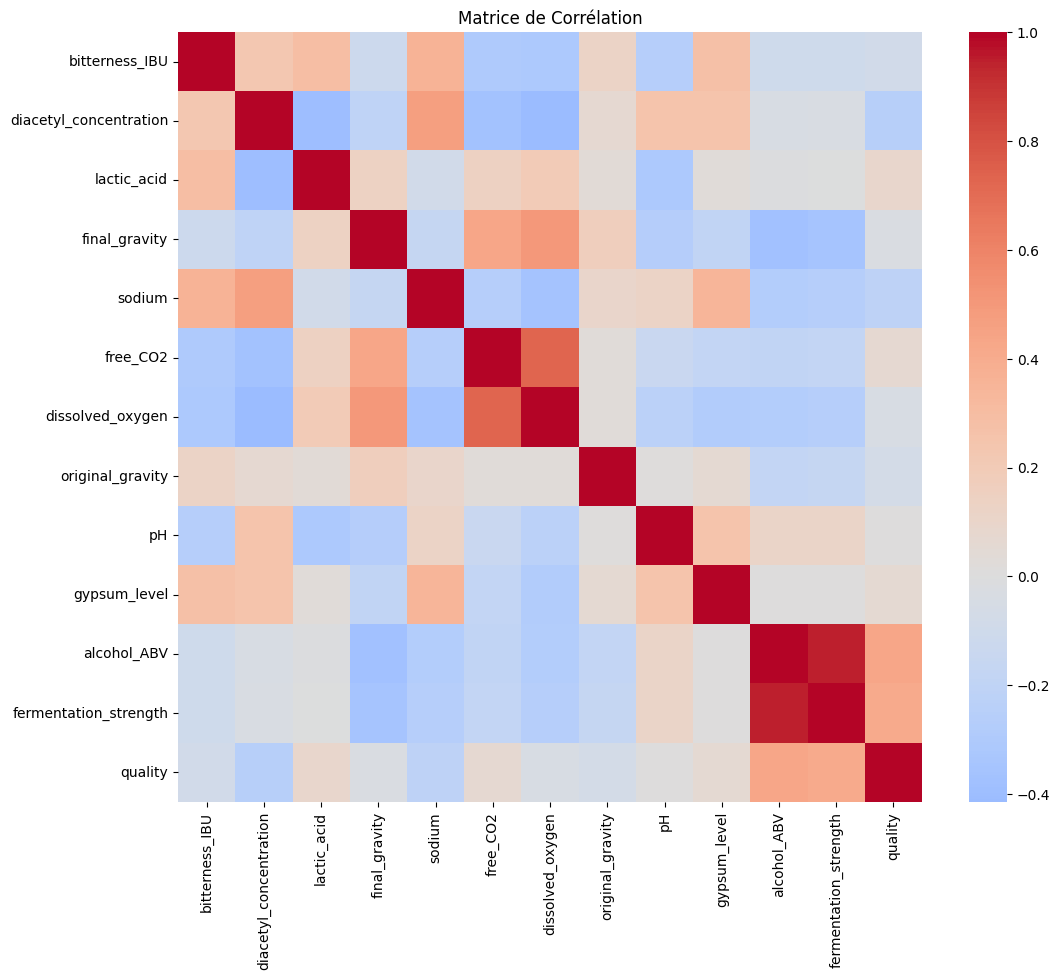

Corrélations avec la qualité :
alcohol_ABV               0.431761
fermentation_strength     0.413546
lactic_acid               0.093430
free_CO2                  0.067375
gypsum_level              0.055774
pH                        0.010393
final_gravity            -0.024665
dissolved_oxygen         -0.040384
original_gravity         -0.071056
bitterness_IBU           -0.085501
sodium                   -0.213499
diacetyl_concentration   -0.252476
Name: quality, dtype: float64
Importance des caractéristiques selon Random Forest :
alcohol_ABV               0.124841
fermentation_strength     0.102607
diacetyl_concentration    0.101217
free_CO2                  0.083883
dissolved_oxygen          0.081181
final_gravity             0.080724
gypsum_level              0.079495
pH                        0.074924
lactic_acid               0.074658
bitterness_IBU            0.073242
sodium                    0.067957
original_gravity          0.055271
dtype: float64


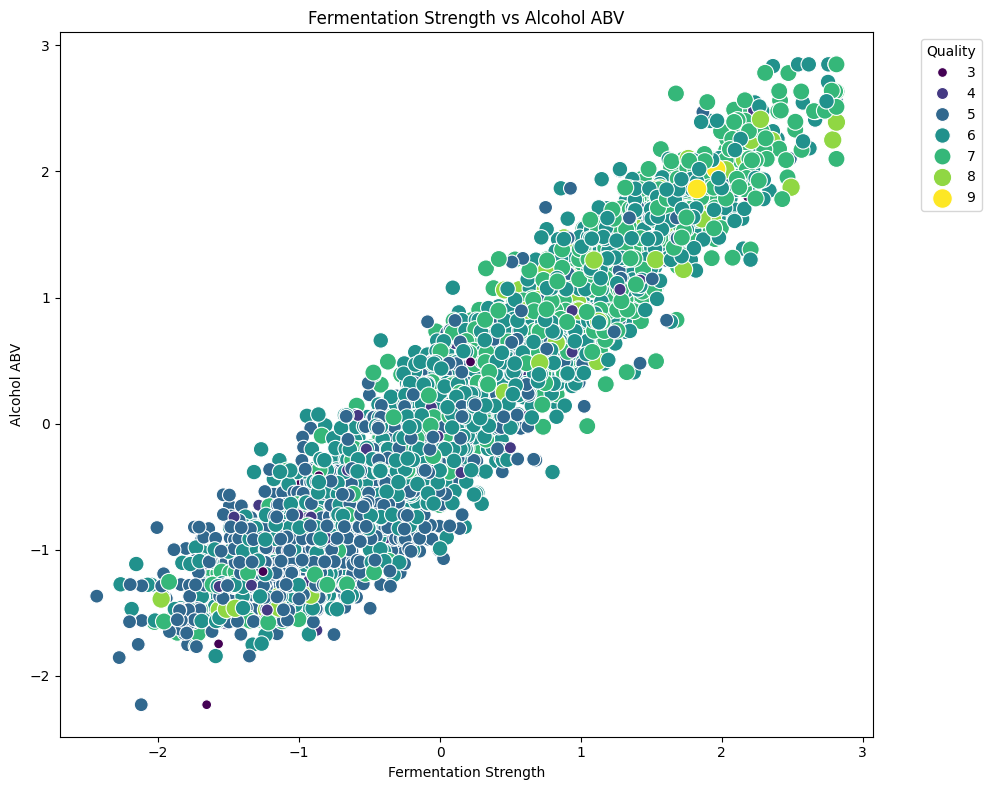

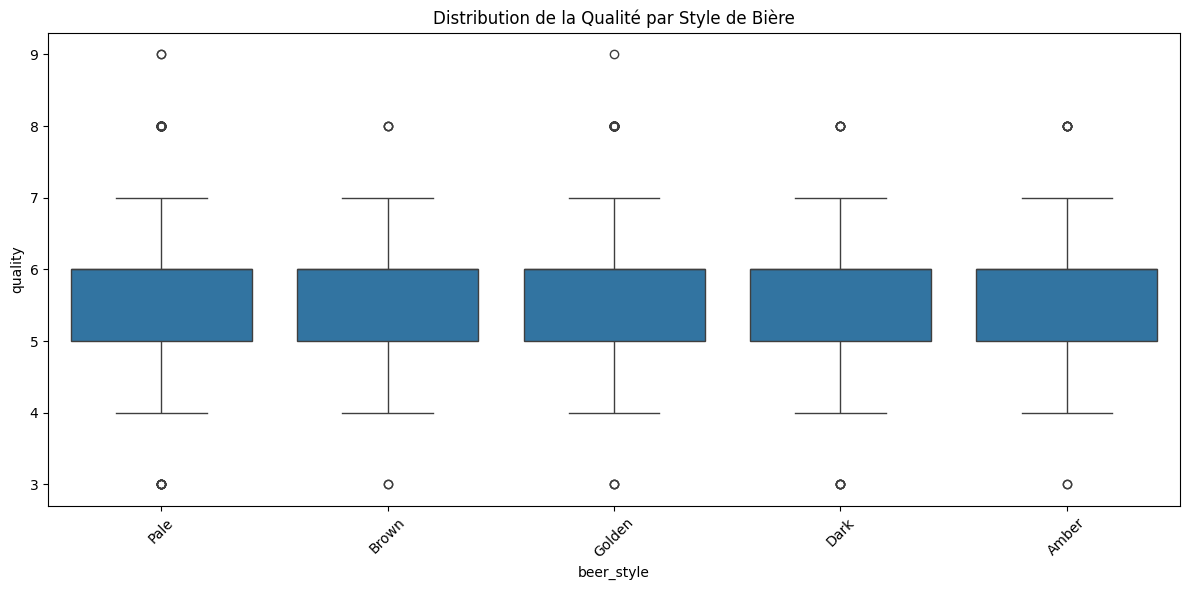

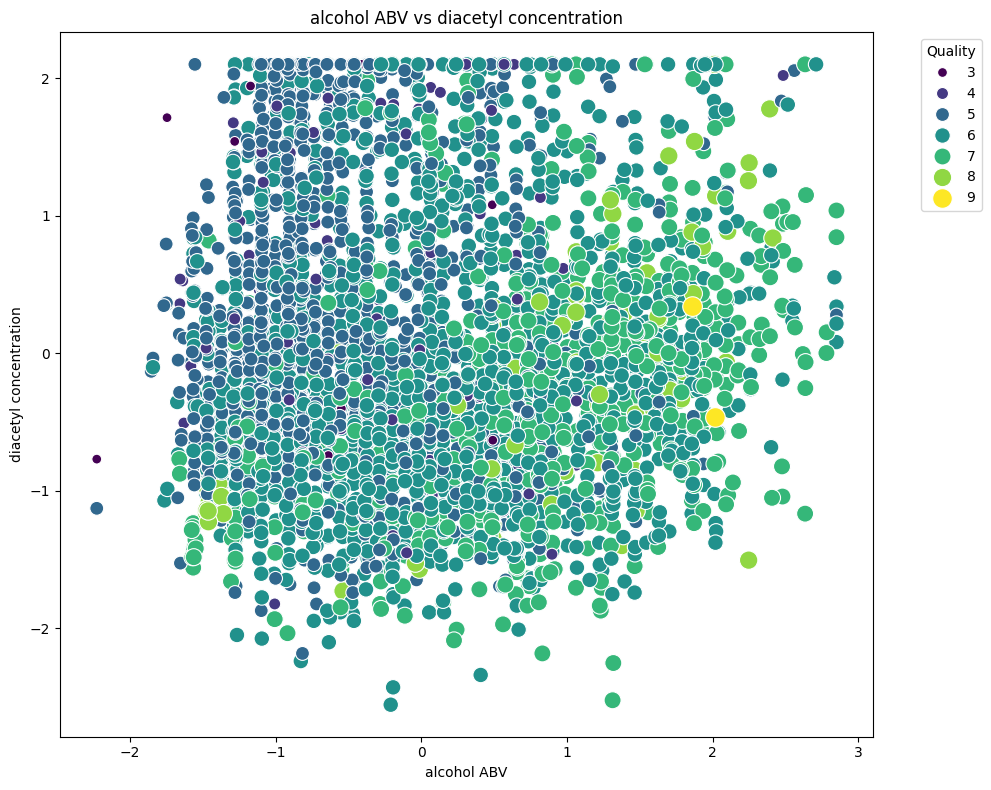

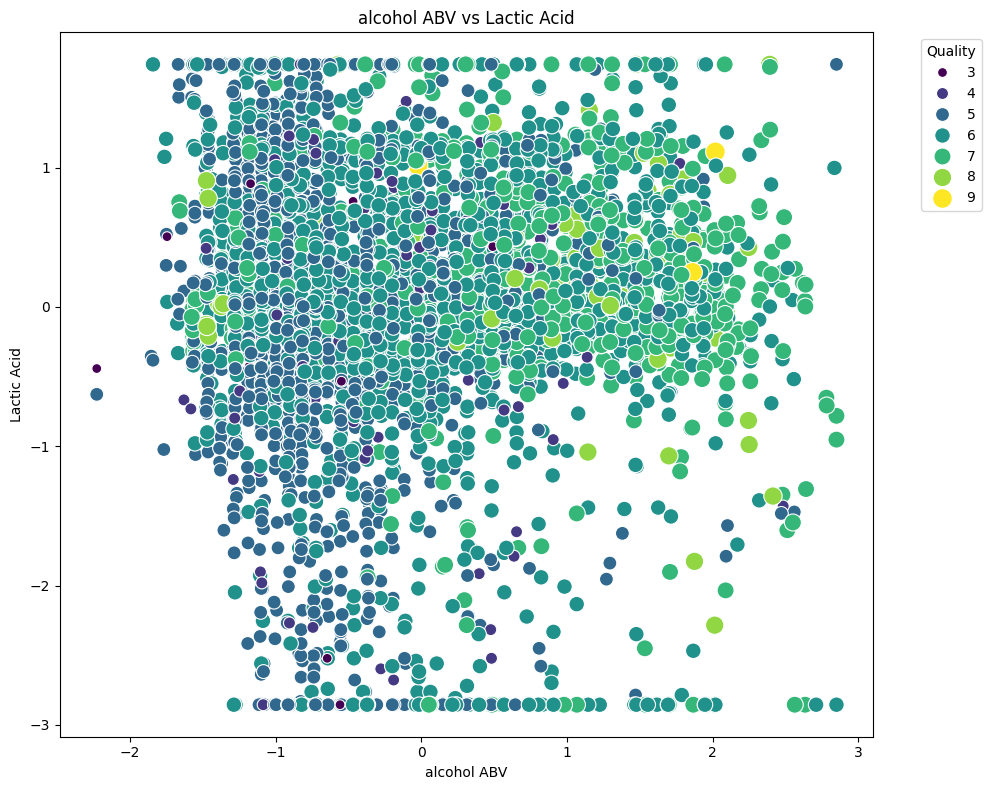

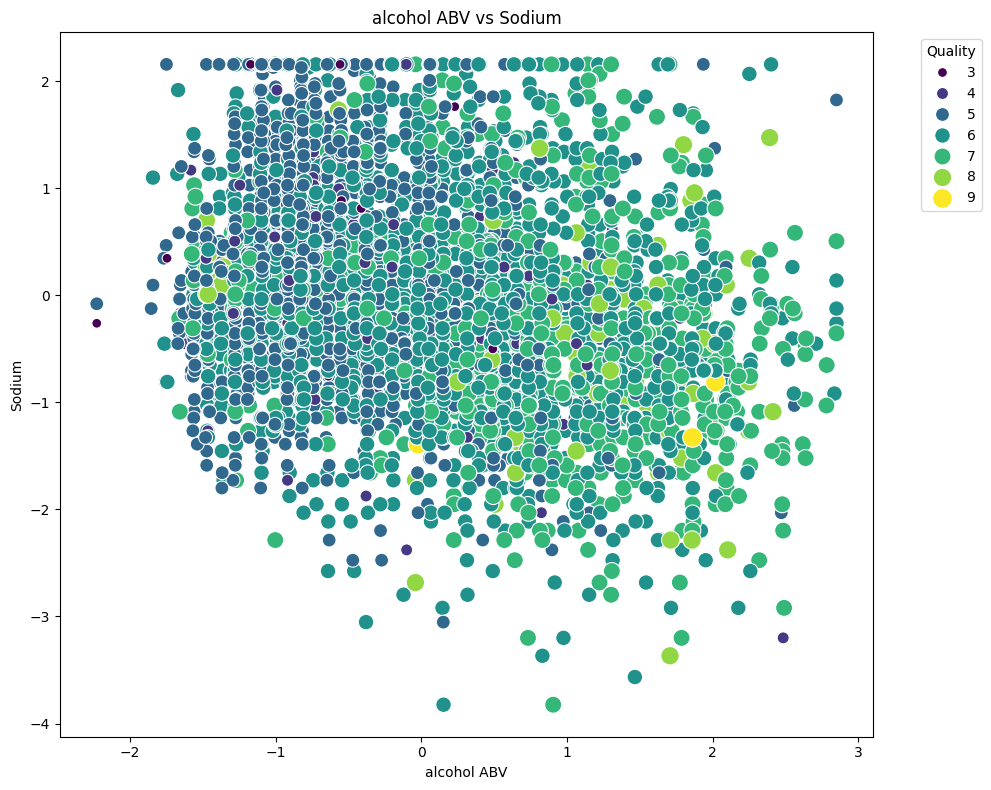

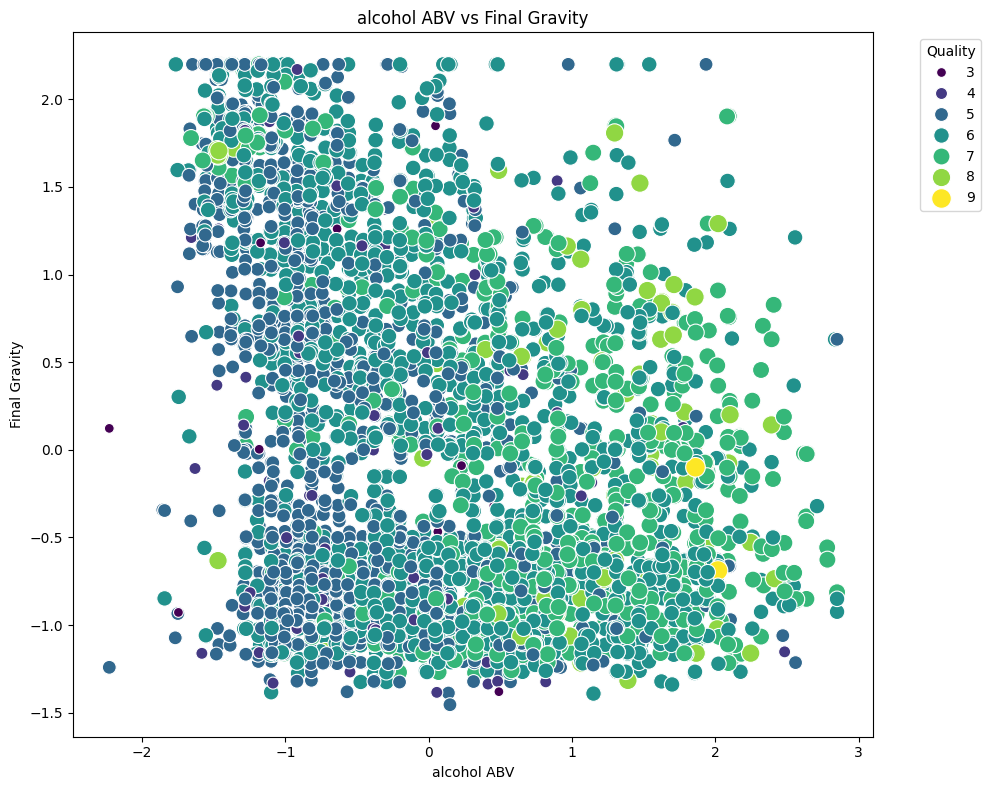

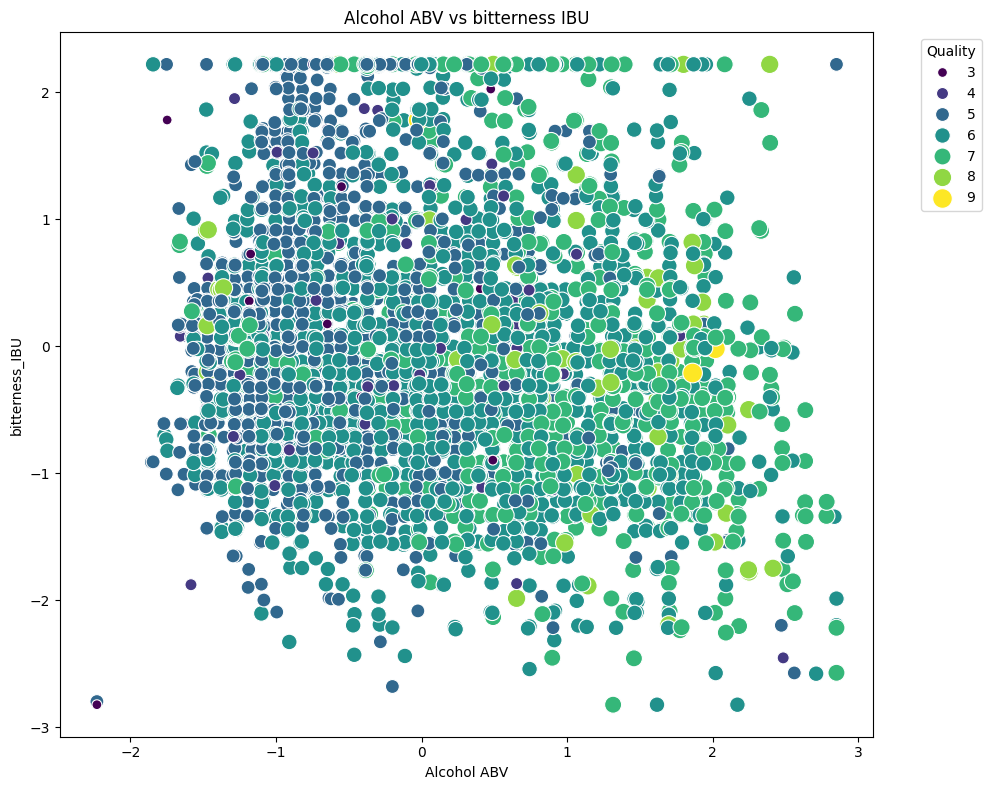

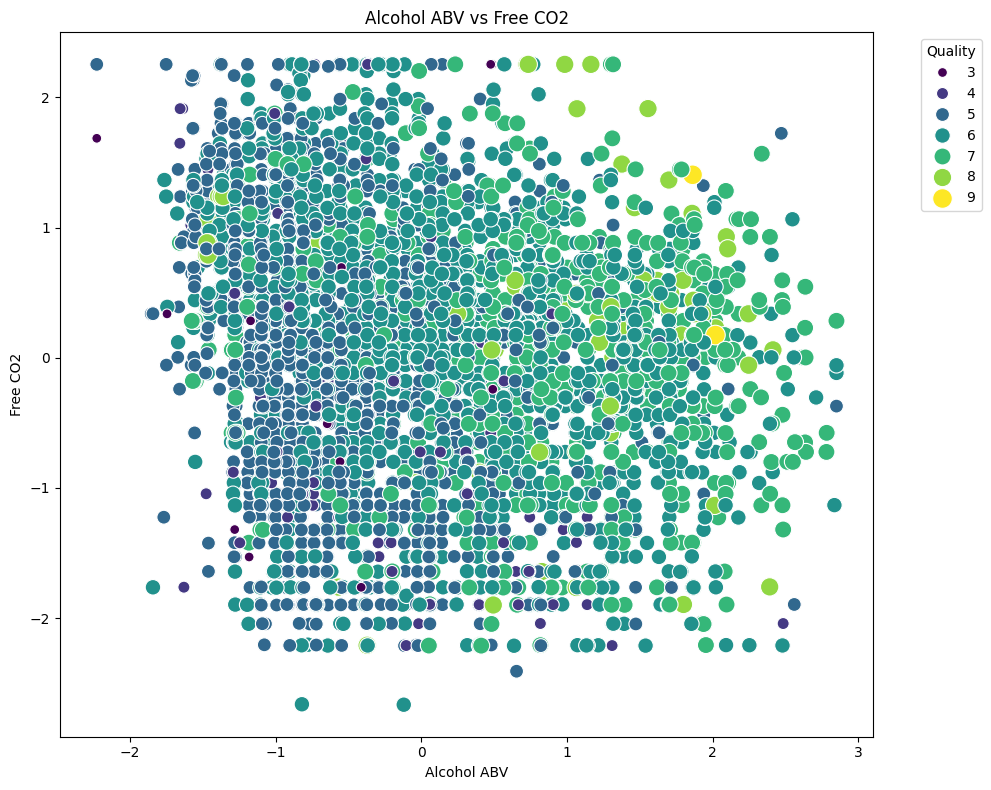

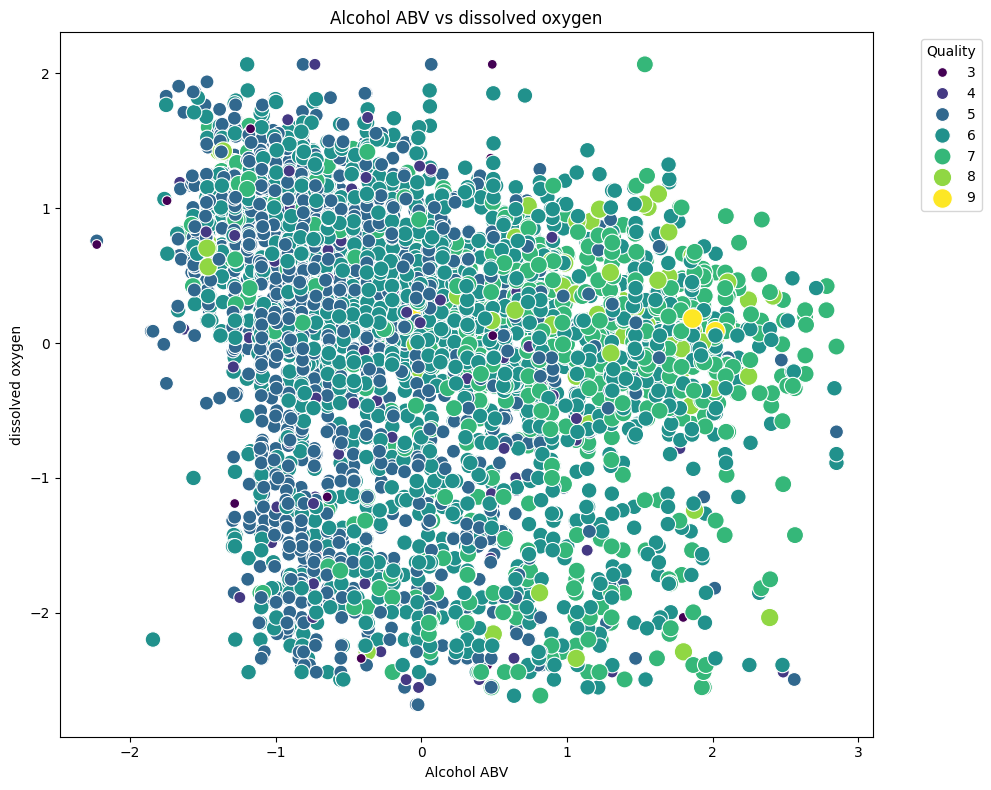

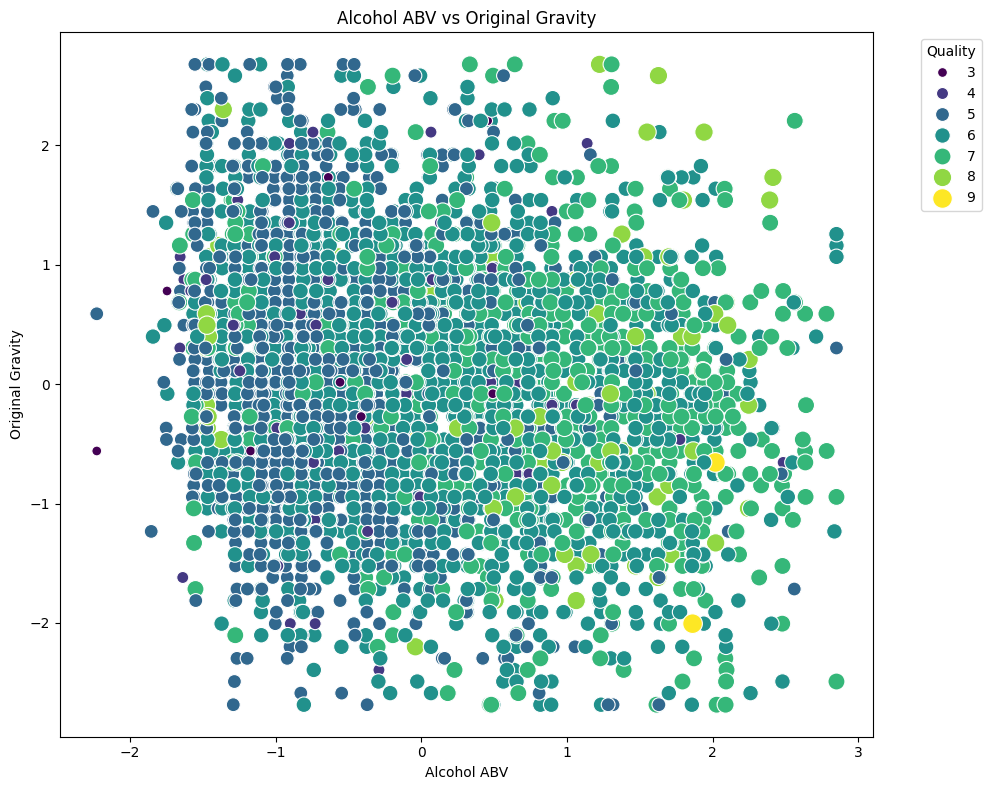

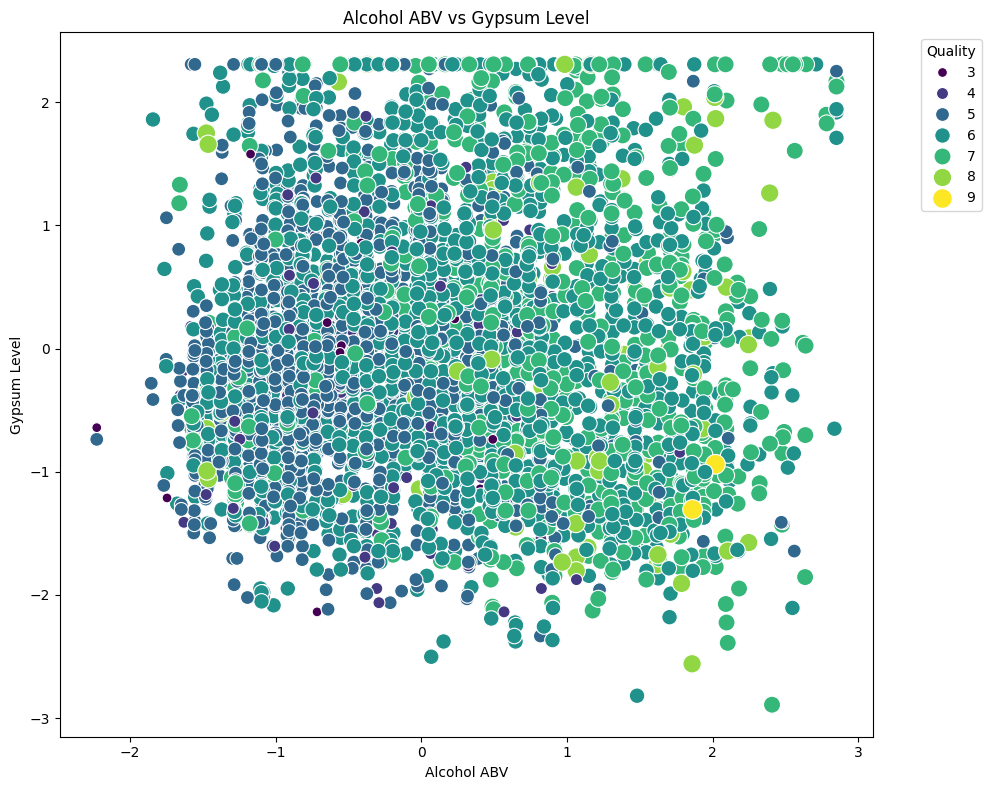

,free_CO2,alcohol_ABV,dissolved_oxygen,diacetyl_concentration,final_gravity
0,-0.178645,0.823341,0.730901,0.854837,1.212907
1,0.693219,0.298231,0.363272,-0.762639,0.390133
2,-0.723787,-0.650935,-0.408665,1.921267,-0.597662
3,0.390773,1.625367,-0.042425,-0.591845,-0.971355
4,-1.640626,1.231078,-2.200605,-1.129078,-0.890067
...,...,...,...,...,...
4464,0.545940,-0.378757,0.165835,-1.148410,1.637918
4465,-0.436957,-0.634033,-1.371008,0.596287,-0.631576
4466,1.019933,-0.728140,1.167697,0.296944,-0.768521
4467,0.974204,0.806016,0.579104,-1.812568,-0.737440


quality
6    1985
5    1496
7     755
4     116
8      93
3      21
9       3
Name: count, dtype: int64


In [182]:
####################################################################
###############   À compléter   ####################################
####################################################################

# Fonction pour détecter et clipper les valeurs aberrantes
def clip_outliers(df, num_cols):
    # On tire les valeurs plus basse que la borne basse pour égaler
    # la borne basse et même chose pour les valeurs plus hautes que 
    # la borne haute
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

# Fonction du pipeline de pretraitement
def data_processor(df):
  df = df.copy()
  # 1. Séparation des données num et cat
  num_cols = ['bitterness_IBU', 'diacetyl_concentration', 'lactic_acid',
                  'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen',
                  'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV',
                    'fermentation_strength']
  cat_cols = ['beer_style']

  # Encodage onehot des données catégorielles
  ohe = OneHotEncoder(sparse_output=False)
  beer_style_encoded = ohe.fit_transform(df[cat_cols])
  cat_columns_names = ohe.get_feature_names_out(cat_cols)

  cat_df = pd.DataFrame(
      beer_style_encoded,
      columns=cat_columns_names,
      index=df.index
  )

  # Transformation des données numériques (plusieurs visualisations
  # ont été faites pour choisir la transformation)
  df[num_cols] = np.sqrt(df[num_cols])

  # Imputation des données na (aucune donc commenté)
  # imputer = SimpleImputer(strategy='mean')
  # df[num_cols] = imputer.fit_transform(df[num_cols])

  # Standardisation pour les données numériques (on met les variables
  # à la même échelle)
  scaler = StandardScaler()
  features_scaled = scaler.fit_transform(df[num_cols])
  num_df = pd.DataFrame(features_scaled, columns=num_cols, index=df.index)

  # On crée une autre table qui garder toutes les caractéristiques pour la visualisation
  processed_df = pd.concat([num_df, cat_df], axis=1)

  # Ici, on choisit les caractéristiques que l'ont veut gardé pour nos modèles. Cette étape a 
  # été revues plusieurs fois après visualisation de la matrice de corrélation et importance
  # des données dans randomForrest
  features_df = processed_df[['free_CO2', 'alcohol_ABV', 'dissolved_oxygen', 'diacetyl_concentration', 'final_gravity']].copy()

  return features_df, num_cols, processed_df

# Prétraitement des données
train_df = pd.read_csv('data/train.csv', delimiter=';')

# On clip les valeurs aberrantes avant le process des datas
num_cols = ['bitterness_IBU', 'diacetyl_concentration', 'lactic_acid',
                  'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen',
                  'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV',
                    'fermentation_strength']
train_df = clip_outliers(train_df, num_cols)

# On fait passer le train_df dans le pipeline de prétraitement
features_df, num_cols, processed_df = data_processor(train_df)

 # On reconstruit un df avec la colonne cible pour faire des 
# visualisations de nos données transformées
processed_df = pd.concat([processed_df, train_df['quality']], axis=1)

# Détermination des caractéristiques importantes
# Visualisation de la matrice de corrélation entre les caractéristiques et la qualité
plt.figure(figsize=(12, 10))
correlation_matrix = train_df[num_cols + ['quality']].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Matrice de Corrélation')
plt.show()

quality_correlations = correlation_matrix['quality'].drop('quality').sort_values(ascending=False)
print("Corrélations avec la qualité :")
print(quality_correlations)
# On remarque qu'il y a une forte corrélation entre les caractéristiques alcohol_ABV et fermentation_strenght
# On les considère donc comme redondantes


# On regarde l'importance des caractéristique selon le modèle de randomForestClassifier

# Utilise toutes les features prétraitées
X = train_df[num_cols]
y = train_df['quality']

# Entrainement du modèle
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X, y)

# Importance des features
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Importance des caractéristiques selon Random Forest :")
print(importances.head(15))

# QUELQUES VISUALISATIONS
# Visualisation de la relation entre fermentation_strength et alcohol_ABV
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='fermentation_strength', y='alcohol_ABV',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Fermentation Strength vs Alcohol ABV')
plt.xlabel('Fermentation Strength')
plt.ylabel('Alcohol ABV')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Linéaire donc redondant?

# Visualisation de la distribution de la qualité par style de bière
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df, x='beer_style', y='quality')
plt.title('Distribution de la Qualité par Style de Bière')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# On remarque que la distribution de la qualité est la même pour
# chaque style, on peut donc ne pas prendre en compte cette
# caractéristique

# Graph alcohol_ABV vs diacetyle_concentration
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='diacetyl_concentration',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('alcohol ABV vs diacetyl concentration')
plt.xlabel('alcohol ABV')
plt.ylabel('diacetyl concentration')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Aucune conclusion

# Graph dissolbed_oxygen and lactic acid
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='lactic_acid',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('alcohol ABV vs Lactic Acid')
plt.xlabel('alcohol ABV')
plt.ylabel('Lactic Acid')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Aucune conclusion

# Graph diacetyl_concentration and sodium
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='sodium',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('alcohol ABV vs Sodium')
plt.xlabel('alcohol ABV')
plt.ylabel('Sodium')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Aucune conclusion

# Graph original gravity and final gravity
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='final_gravity',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('alcohol ABV vs Final Gravity')
plt.xlabel('alcohol ABV')
plt.ylabel('Final Gravity')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Aucune conclusion

# Graph alcohol ABV ve Bitterness IBU
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='bitterness_IBU',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Alcohol ABV vs bitterness IBU')
plt.xlabel('Alcohol ABV')
plt.ylabel('bitterness_IBU')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Aucune conclusion

# Graph alcohol ABV vs free CO2
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='free_CO2',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Alcohol ABV vs Free CO2')
plt.xlabel('Alcohol ABV')
plt.ylabel('Free CO2')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Graph alcohol ABV vs dissolved oxygen
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='dissolved_oxygen',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Alcohol ABV vs dissolved oxygen')
plt.xlabel('Alcohol ABV')
plt.ylabel('dissolved oxygen')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Graph alcohol ABV vs original gravity
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='original_gravity',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Alcohol ABV vs Original Gravity')
plt.xlabel('Alcohol ABV')
plt.ylabel('Original Gravity')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Graph alcohol ABV vs gysum level
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='gypsum_level',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Alcohol ABV vs Gypsum Level')
plt.xlabel('Alcohol ABV')
plt.ylabel('Gypsum Level')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


display(features_df)

# Observation du nombre d'échantillons par classe de qualité
print(train_df['quality'].value_counts())
# On remarque un déséquilibre des classes flagrant entre les classes








## Préparer les Données d'Entraînement et de Validation

Divisez vos données en ensembles d'entraînement et de validation.

In [183]:
# Séparation des cibles et des caractéristiques
X = features_df
y = train_df['quality']


# On supprime les classes 3 et 9 puisqu'elles ne contiennent pas assez 
# de données pour être utiles (donc nos modèles ne prédiront jamais
# correctement les classes 1, 2, 3, 9 et 10)
classes_to_remove = [3, 9]
train_df_filtered = train_df[~train_df['quality'].isin(classes_to_remove)]
X_filtered = features_df.loc[train_df_filtered.index]
y_filtered = train_df_filtered['quality']

# On équilibre nos données avec SMOTE qui rajoute des données
# dans les classes sous-représentées
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_filtered, y_filtered)

# On sépare les données en ensembe d'entrainement et de validation
# en s'assurant que les classes soient également représentées dans
# les deux cas.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_smote, y_smote,
    test_size=0.2, random_state=42, stratify=y_smote
)



## Entraîner les Modèles

Entraînez et comparez plusieurs modèles d'apprentissage automatique.

In [ ]:
####################################################################
####################################################################
###############   À compléter   ####################################
####################################################################
####################################################################

# 1. K-nn
# On test les voisins de 1 à 31
k = np.arange(1, 31)

# Trouver la meilleure valeur de k entre 1 et 31
best_accuracy = 0
for k_value in k:
    neigh = KNeighborsClassifier(n_neighbors=k_value, weights='distance')
    neigh.fit(X_train, y_train)
    y_pred_knn = neigh.predict(X_valid)
    accuracy_knn = accuracy_score(y_valid, y_pred_knn)
    # Sauvegarder le meilleur modèle
    if accuracy_knn > best_accuracy:
        best_accuracy = accuracy_knn
        best_k = k_value
        knn_best_predictions = y_pred_knn
        best_model = neigh

# On imprime l'accuracy avec ses hyperparamètres et la matrice de classification
print("Best k for K-nn: ", best_k)
print("K-nn Accuracy:", best_accuracy)
print("Classification Report KNN:\n", classification_report(y_valid, knn_best_predictions))

# 2. Parzen
radius = np.arange(0.1, 5.1, 0.1)
# trouver la meilleure valeur de radius entre 0.1 et 10.0
accuracies_parzen = []
for radius_value in radius:
    # liste pour stocker les kde de chaque classe
    kdes = []

    # un kde par classe
    for class_idx in range(7):  # Classes 0-6
        mask = (y_train == class_idx)
        if np.sum(mask) > 0:
            kde = KernelDensity(bandwidth=radius_value, kernel='gaussian')
            kde.fit(X_train[mask])
            kdes.append(kde)
        else:
            kdes.append(None)

    # calcul des densités
    log_probs = np.zeros((len(X_valid), 7))
    for class_idx in range(7):
        if kdes[class_idx] is not None:
            log_probs[:, class_idx] = kdes[class_idx].score_samples(X_valid)
        else:
            log_probs[:, class_idx] = -np.inf

    # choisir la classe avec la plus haute densité
    y_pred_parzen = np.argmax(log_probs, axis=1)
    accuracy_parzen = accuracy_score(y_valid, y_pred_parzen)
    accuracies_parzen.append(accuracy_parzen)

# on trouve l'indice du meilleur radius
radius_index = np.argmax(accuracies_parzen)
best_radius = radius[radius_index]

# On imprime l'accuracy avec ses hyperparamètres et la matrice de classification
print(f"Best radius for Parzen: {best_radius}")
print(f"Parzen Accuracy: {accuracies_parzen[radius_index]:.4f}")
print("Classification Report Parzen:\n", classification_report(y_valid, y_pred_parzen))


# 3. SVM

# On définit les noyaux que l'on veut tester
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
# On définit les valeurs de C que l'on veut tester
c_values = [0.01, 0.1, 1, 10, 100]
best_model_svm = None
best_acc_svm = 0

# On teste toutes les combinaisons des hyperparamètres définis
for kernel in kernels:
    for c in c_values:
        if kernel == 'poly':
            svm_model = SVC(kernel=kernel, C=c, degree=3, gamma='scale', class_weight="balanced")
        else:
            svm_model = SVC(kernel=kernel, C=c, gamma='scale', class_weight="balanced")

        svm_model.fit(X_train, y_train)
        y_pred = svm_model.predict(X_valid)
        acc = accuracy_score(y_valid, y_pred)
        # On garde le meilleur modèle
        if acc > best_acc_svm:
            best_acc_svm = acc
            best_model_svm = svm_model
            best_params_svm = (kernel, c)
            best_prediction_svm = y_pred

# On imprime l'accuracy avec ses hyperparamètres et la matrice de classification
print("Best Kernel: ", best_params_svm[0])
print("Best C: ", best_params_svm[0])
print("SVM accuracy: ", best_acc_svm)
print("\nClassification Report SVM:")
print(classification_report(y_valid, best_prediction_svm))

# 4 Regression Logistique

# On définis les valeurs de c et solvers que l'on veut tester
c_values = [0.01, 0.1, 1, 10, 100]
solvers = ['lbfgs', 'newton-cg', 'saga']

best_logreg_acc = 0

for solver in solvers:
    for c in c_values:
        logreg = LogisticRegression(
            penalty='l2',
            C=c,
            solver=solver,
            max_iter=2000,
            multi_class='multinomial',
            class_weight="balanced"
        )
        logreg.fit(X_train, y_train)
        y_pred = logreg.predict(X_valid)
        acc = accuracy_score(y_valid, y_pred)
        if acc > best_logreg_acc:
            best_logreg_acc = acc
            best_logreg = logreg
            best_params_logreg = [solver, c]
            best_prediction_logreg = y_pred
        

best_logreg.fit(X_train, y_train)
y_pred_logreg = best_logreg.predict(X_valid)
valid_acc_logreg = accuracy_score(y_valid, y_pred_logreg)

print("Best Solver:", best_params_logreg[0])
print("Best C:", best_params_logreg[1])
print("Logreg Accuracy Logreg:", best_logreg_acc)
print("Classification Report:\n", classification_report(y_valid, y_pred_logreg))

# 5. Random Forest Classifier

# Grille des parametres que l'on veut tester
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, 30]
}

best_acc_rf = 0
best_params = None

for n in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            max_depth=depth,
            min_samples_split=10,  # Assez haut pour éviter arbres trop profonds
            min_samples_leaf=3,    # entre deux pour garder modele flexible mais pas trop
            class_weight="balanced",
            random_state=42
        )
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_valid)
        acc_rf = accuracy_score(y_valid, y_pred)

        if acc_rf > best_acc_rf:
            best_acc_rf = acc_rf
            best_rf = rf
            best_params = [n, depth]

print("RF n_estimators:", best_params[0])
print("RF depth:", best_params[1])

best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_valid)
valid_acc_rf = accuracy_score(y_valid, y_pred_rf)

print("Random Forest Best Valid Accuracy:", best_acc_rf)
print("Classification Report:\n", classification_report(y_valid, y_pred_rf))





Best k for K-nn:  1
K-nn Accuracy: 0.8322418136020151
Classification Report KNN:
               precision    recall  f1-score   support

           4       0.88      0.96      0.92       397
           5       0.76      0.74      0.75       397
           6       0.69      0.57      0.63       397
           7       0.86      0.89      0.87       397
           8       0.94      0.99      0.97       397

    accuracy                           0.83      1985
   macro avg       0.82      0.83      0.83      1985
weighted avg       0.82      0.83      0.83      1985

Best radius for Parzen: 0.1
Parzen Accuracy: 0.4811
Classification Report Parzen:
               precision    recall  f1-score   support

           4       0.39      0.60      0.47       397
           5       0.43      0.40      0.41       397
           6       0.24      0.62      0.35       397
           7       0.00      0.00      0.00       397
           8       0.00      0.00      0.00       397

    accuracy        

/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/alixloungnarath/miniconda3/envs/.venv/li

Best Solver: lbfgs
Best C: 0.1
Logreg Accuracy Logreg: 0.4332493702770781
Classification Report:
               precision    recall  f1-score   support

           4       0.53      0.56      0.54       397
           5       0.45      0.48      0.47       397
           6       0.33      0.26      0.29       397
           7       0.36      0.33      0.34       397
           8       0.46      0.54      0.49       397

    accuracy                           0.43      1985
   macro avg       0.43      0.43      0.43      1985
weighted avg       0.43      0.43      0.43      1985

RF n_estimators: 100
RF depth: 20
Random Forest Best Valid Accuracy: 0.7899244332493702
Classification Report:
               precision    recall  f1-score   support

           4       0.88      0.92      0.90       397
           5       0.75      0.71      0.73       397
           6       0.62      0.53      0.58       397
           7       0.76      0.80      0.78       397
           8       0.90      0

## Évaluer les Modèles

Analysez la performance de votre meilleur modèle (voir README.md pour les directives d'évaluation).

In [178]:
####################################################################
###############   À compléter   ####################################
####################################################################

# Maintenant on prévoit les y de test
# Charger les données de test
test_df = pd.read_csv('data/test.csv', delimiter=';')

# On prépare les données de la même facon que X_train
X_test, _, _= data_processor(test_df)

# On refiltre de la meme facon que nous avions filtré x_train et y_train
# l'ensemble de nos données X et y

# On réentraine le modèle sur toutes les données d'entraînement (X, y)
final_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

# On entraine une derniere fois le meilleur modele sur l'ensemble de nos données (qui ont été
# filtrées et smote)
final_model.fit(X_smote, y_smote)

# Évaluer la performance sur les données d'entraînement (non filtrées)
y_train_pred = final_model.predict(X)
train_accuracy = accuracy_score(y, y_train_pred)
print("Final Model Training Accuracy: {:.4f}".format(train_accuracy))


# Classification détaillée
print("Classification Report sur y_valid :")
print(classification_report(y, y_train_pred))

# Prédiction X_test
prediction = final_model.predict(X_test)


/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)


Final Model Training Accuracy: 0.8888
Classification Report sur y_valid :
              precision    recall  f1-score   support

           3       0.00      0.00      0.00        21
           4       0.61      1.00      0.76       116
           5       0.90      0.90      0.90      1496
           6       0.94      0.86      0.90      1985
           7       0.85      0.93      0.89       755
           8       0.66      0.99      0.79        93
           9       0.00      0.00      0.00         3

    accuracy                           0.89      4469
   macro avg       0.57      0.67      0.61      4469
weighted avg       0.89      0.89      0.89      4469



## Générer les Prédictions pour la Soumission Kaggle

Créez un fichier CSV avec les colonnes : `id` et `quality` (voir README.md pour les détails du format).

In [177]:

####################################################################
###############   À compléter   ####################################
####################################################################

output_df = pd.DataFrame({
    'id': range(len(prediction)),  # les id sont les index
    'quality': prediction
})

# Sauvegarder en CSV
output_df.to_csv('predictions.csv', index=False)

---
Bonne chance pour la compétition ! 🍺
